<h2>Load libraries and dataset</h2>

In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import Fido, attrs as a
from astropy import units as u
from astropy.coordinates import SkyCoord
import sunpy_soar
from glob import glob
from IPython.display import HTML
from astropy.io import fits
from astropy.time import Time
from datetime import datetime
#from pastamarkers import pasta, salsa
from stixpy.product import Product
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
import scipy

In [3]:
plt.close('all')

In [4]:
short_exposure_images = glob(r'C:\python_code\hrishort\*.fits')

In [5]:
initial_map = sunpy.map.Map(short_exposure_images[200])

In [6]:
tr_x=3170
tr_y=-620
bl_x=3050
bl_y=-800

In [7]:
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=initial_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=initial_map.coordinate_frame)
short_exposure_map_seq = initial_map.submap(bottom_left=bottom_left, top_right=top_right)
#short_exposure_map_seq.quicklook()

In [8]:
second_map = sunpy.map.Map(short_exposure_images[201])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=second_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=second_map.coordinate_frame)
second_map_crop = second_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map([short_exposure_map_seq, second_map_crop], sequence = True)
third_map = sunpy.map.Map(short_exposure_images[202])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=third_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=third_map.coordinate_frame)
third_map_crop = third_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [third_map_crop], sequence = True)

In [9]:
for i in range(98):
    next_map = sunpy.map.Map(short_exposure_images[203+i])
    top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=next_map.coordinate_frame)
    bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=next_map.coordinate_frame)
    next_map_crop = next_map.submap(bottom_left=bottom_left, top_right=top_right)
    short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [next_map_crop], sequence = True)

In [10]:
euitimes = []
for i in range(101):
    hdul = fits.open(short_exposure_images[200+i])
    hdu1 = hdul[1]
    euitimes.append(hdu1.header["DATE-BEG"])
    hdul.close()

In [11]:
euitimes = Time(euitimes).to_datetime()

In [12]:
masked_map_seq_3 = short_exposure_map_seq

<h2>Extract lightcurves</h2>

In [13]:
lightcurves = np.zeros([293*397, len(masked_map_seq_3)])

In [14]:
lightcurve_max = 0
for i in range(290):
    for j in range(395):
        for k in range(len(masked_map_seq_3)):
            #print(masked_map_seq_3[k].data[j,i])
            lightcurves[i*j, k] = masked_map_seq_3[k].data[j,i]
            if masked_map_seq_3[k].data[j,i] > lightcurve_max:
                lightcurve_max = masked_map_seq_3[k].data[j,i]

<h2>Unordered plot of lightcurves</h2>

In [16]:
lightcurve_maxs = np.zeros([293*397])
for n in range(293*397):
    maxx = 0
    for k in range(100):
        if lightcurves[n, k] > maxx:
            maxx = lightcurves[n,k]
            lightcurve_maxs[n] = lightcurves[n,k]
            #print(lightcurve_maxs[n])

In [17]:
non_zero_lightcurves = []
for n in range(len(lightcurve_maxs)):
    if lightcurve_maxs[n] > 0:
        non_zero_lightcurves.append(lightcurves[n,])

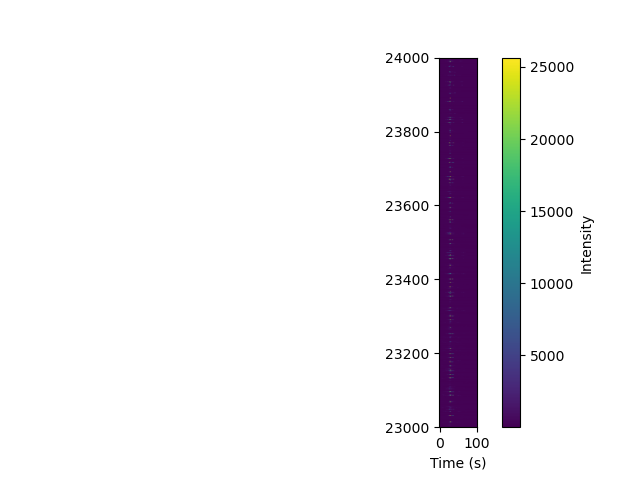

In [18]:
fig, ax = plt.subplots()
im = ax.imshow(non_zero_lightcurves)
cbar = ax.figure.colorbar(im, ax=ax, label="Intensity")

# # Show all ticks and label them with the respective list entries
# ax.set_xticks([0,50,100], labels="Time (s)",
#                rotation=45, ha="right", rotation_mode="anchor")
# ax.set_yticks(range(len(vegetables)), labels=vegetables)

# # Loop over data dimensions and create text annotations.
# for i in range(len(vegetables)):
#     for j in range(len(farmers)):
#         text = ax.text(j, i, harvest[i, j],
#                        ha="center", va="center", color="w")

# ax.set_title("Harvest of local farmers (in tons/year)")
ax.set_xlabel("Time (s)")
#ax.set_xlim([0,70])
ax.set_ylim([23000,24000])
# fig.tight_layout()
plt.show()

<h2>Ordered plot of lightcurves</h2>

In [19]:
peak_2ten4 = []
peak_1ten4 = []
peak_5ten3 = []
peak_2ten3 = []
peak_1ten3 = []
peak_1ten2 = []
peak_ten = []
peak_below = []

In [20]:
count = 0
for n in range(len(lightcurve_maxs)):
    if lightcurve_maxs[n] > 20000:
        peak_2ten4.append(lightcurves[n,])
        #print(lightcurve_maxs[n], "> 20000")
    elif lightcurve_maxs[n] > 10000:
        peak_1ten4.append(lightcurves[n,])
        #print(lightcurve_maxs[n], "> 10000")
    elif lightcurve_maxs[n] > 5000:
        peak_5ten3.append(lightcurves[n,])
       # print(lightcurve_maxs[n], "> 5000")
    elif lightcurve_maxs[n] > 2000:
        peak_2ten3.append(lightcurves[n,])
        #print(lightcurve_maxs[n], "> 2000")
    elif lightcurve_maxs[n] > 1000:
        peak_1ten3.append(lightcurves[n,])
       # print(lightcurve_maxs[n], "> 1000")
    elif lightcurve_maxs[n] > 100:
        peak_1ten2.append(lightcurves[n,])
    elif lightcurve_maxs[n] > 10:
        peak_ten.append(lightcurves[n,])
    elif lightcurve_maxs[n] == 0:
        count = count + 1
        pass
    else:
        peak_below.append(lightcurves[n,])
        #print(lightcurve_maxs[n], "< 1000")

In [21]:
ordered_lightcurves = []
ordered_lightcurves = peak_2ten4
print(len(ordered_lightcurves))

for n in range(len(peak_1ten4)):
    ordered_lightcurves.append(peak_1ten4[n])
print(len(ordered_lightcurves))

for n in range(len(peak_5ten3)):
    ordered_lightcurves.append(peak_5ten3[n])
print(len(ordered_lightcurves))

for n in range(len(peak_2ten3)):
    ordered_lightcurves.append(peak_2ten3[n])
print(len(ordered_lightcurves))

for n in range(len(peak_1ten3)):
    ordered_lightcurves.append(peak_1ten3[n])
print(len(ordered_lightcurves))

#remove lightcurves with peak less than 1000 by commenting out the below lines
# for n in range(len(peak_1ten2)):
#     ordered_lightcurves.append(peak_1ten2[n])
# print(len(ordered_lightcurves))

#remove lightcurves with peak less than 100 by commenting out the below lines
# for n in range(len(peak_ten)):
#     ordered_lightcurves.append(peak_ten[n])
# print(len(ordered_lightcurves))

# for n in range(len(peak_below)):
#     ordered_lightcurves.append(peak_below[n])
# print(len(ordered_lightcurves))


93
172
256
395
594


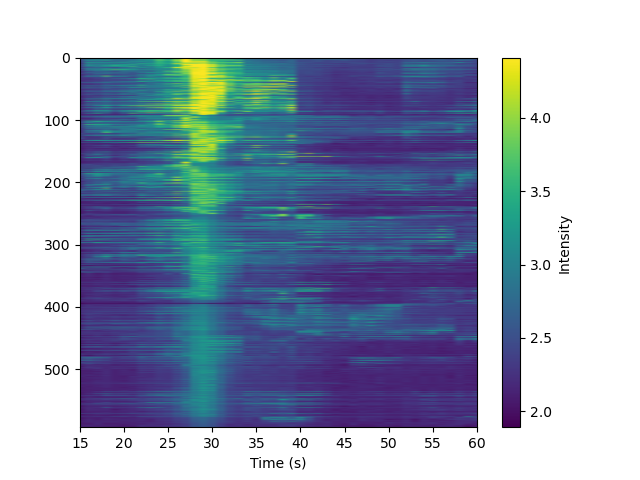

In [22]:
fig, ax = plt.subplots()
im = ax.imshow(np.log10(ordered_lightcurves), aspect = "auto")
cbar = ax.figure.colorbar(im, ax=ax, label="Intensity")

# # Show all ticks and label them with the respective list entries
# ax.set_xticks([0,50,100], labels="Time (s)",
#                rotation=45, ha="right", rotation_mode="anchor")
# ax.set_yticks(range(len(vegetables)), labels=vegetables)

# # Loop over data dimensions and create text annotations.
# for i in range(len(vegetables)):
#     for j in range(len(farmers)):
#         text = ax.text(j, i, harvest[i, j],
#                        ha="center", va="center", color="w")

# ax.set_title("Harvest of local farmers (in tons/year)")
ax.set_xlabel("Time (s)")
ax.set_xlim([15,60])
# fig.tight_layout()
plt.show()

<h2>Insert gaps to reflect EUI cadence</h2>

In [23]:
eui_times_gapped = []
for k in range(16):
    eui_times_gapped.append(euitimes[k])
eui_times_gapped.append(datetime(2024,4,5,20,9,32,0))
eui_times_gapped.append(datetime(2024,4,5,20,9,34,0))
for k in range(6):
    index = 16 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,9,48,0))
eui_times_gapped.append(datetime(2024,4,5,20,9,50,0))
for k in range(6):
    index = 22 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,10,4,0))
eui_times_gapped.append(datetime(2024,4,5,20,10,6,0))
for k in range(6):
    index = 28 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,10,20,0))
eui_times_gapped.append(datetime(2024,4,5,20,10,22,0))
for k in range(6):
    index = 34 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,10,36,0))
eui_times_gapped.append(datetime(2024,4,5,20,10,38,0))
for k in range(6):
    index = 40 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,10,52,0))
eui_times_gapped.append(datetime(2024,4,5,20,10,54,0))
for k in range(6):
    index = 46 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,11,8,0))
eui_times_gapped.append(datetime(2024,4,5,20,11,10,0))
for k in range(6):
    index = 52 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,11,24,0))
eui_times_gapped.append(datetime(2024,4,5,20,11,26,0))
for k in range(6):
    index = 58 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,11,40,0))
eui_times_gapped.append(datetime(2024,4,5,20,11,42,0))
for k in range(6):
    index = 64 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,11,56,0))
eui_times_gapped.append(datetime(2024,4,5,20,11,58,0))
for k in range(6):
    index = 70 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,12,12,0))
eui_times_gapped.append(datetime(2024,4,5,20,12,14,0))
for k in range(6):
    index = 76 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,12,28,0))
eui_times_gapped.append(datetime(2024,4,5,20,12,30,0))
for k in range(6):
    index = 82 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,12,44,0))
eui_times_gapped.append(datetime(2024,4,5,20,12,46,0))
for k in range(6):
    index = 88 + k
    eui_times_gapped.append(euitimes[index])
eui_times_gapped.append(datetime(2024,4,5,20,13,00,0))
eui_times_gapped.append(datetime(2024,4,5,20,13,2,0))
for k in range(6):
    index = 94 + k
    eui_times_gapped.append(euitimes[index])

In [24]:
gapped_lightcurves_all = []
for n in range(len(ordered_lightcurves)):
    gapped_lightcurves_ind = []
    for k in range(16):
        gapped_lightcurves_ind.append(ordered_lightcurves[n][k])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 16 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 22 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 28 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 34 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 40 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 46 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 52 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 58 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 64 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 70 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 76 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 82 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 88 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_ind.append(0)
    gapped_lightcurves_ind.append(0)
    for k in range(6):
        index = 94 + k
        gapped_lightcurves_ind.append(ordered_lightcurves[n][index])
    gapped_lightcurves_all.append(gapped_lightcurves_ind)

In [25]:
x_tick_locs = np.linspace(0, len(eui_times_gapped)-1, len(eui_times_gapped))

<h2>Add Xrays</h2>

In [26]:
data_dir = ("C:/python_code/stix_test/stix_test_2/")
file = 'solo_L1_stix-sci-xray-cpd_20240405T200641-20240405T201345_V02_2404056477-61087.fits'
file_bkg = 'solo_L1_stix-sci-xray-cpd_20240409T061238-20240409T071238_V02_2404094915-62999.fits'

In [27]:
stix_cpd = glob(data_dir+file)

In [28]:
stix_cpd_data = Product(stix_cpd)

In [29]:
stix_data_1 = stix_cpd_data.data['counts'].sum(axis=1)
stix_data_energies = stix_data_1.sum(axis=1)

In [30]:
non_thermal_energies = np.zeros(838)
for n in range(838):
    non_thermal_energies[n] = (#stix_data_energies[n, 7].value + stix_data_energies[n, 8].value + stix_data_energies[n, 9].value + stix_data_energies[n, 10].value + stix_data_energies[n, 11].value + stix_data_energies[n, 12].value + 
    stix_data_energies[n, 13].value + stix_data_energies[n, 14].value + stix_data_energies[n, 15].value + stix_data_energies[n, 16].value + stix_data_energies[n, 17].value + stix_data_energies[n, 18].value + stix_data_energies[n, 19].value + 
    stix_data_energies[n, 20].value + stix_data_energies[n, 21].value)

In [31]:
stix_time = (stix_cpd_data.data["time"])

In [32]:
stix_tick = np.arange(0, 494, 4)

2026-04-22 20:03:22 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-22 20:03:22 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


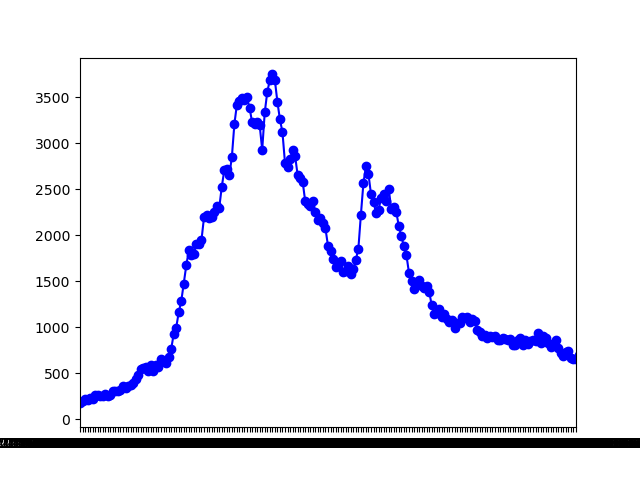

In [33]:
fig8, ax8 = plt.subplots()
ax8.plot(stix_time[274:767].value, non_thermal_energies[274:767], 'bo-')
#ax8.set_xticks(stix_tick, eui_times_labels[4:], rotation=90, ha="right", rotation_mode="anchor")
ax8.set_xlim(stix_tick[16], stix_tick[65])
plt.show()
# for n in range(838):
#     ax8.plot(stix_time[n].value, non_thermal_energies[n])

In [34]:
x_tick_locs = x_tick_locs - 1
plt.close("all")

In [35]:
stix_tick = []
for n in range(50):
    stix_tick.append(4*n)

In [37]:
eui_times_labels = ["20:08:52", "20:08:54", "20:08:56", "20:08:58", "20:09:04", "20:09:06", "20:09:08", "20:09:10", "20:09:12", "20:09:14",
                    "20:09:20", "20:09:22", "20:09:24", "20:09:26", "20:09:28", "20:09:30", "20:09:32", "20:09:34", "20:09:36", "20:09:38",
                    "20:09:36", "20:09:38", "20:09:40", "20:09:42", "20:09:44", "20:09:46", "20:09:48", "20:09:50", "20:09:52", "20:09:54",
                    "20:09:56", "20:09:58", "20:10:00", "20:10:02", "20:10:04", "20:10:06", "20:10:08", "20:10:10", "20:10:12", "20:10:14",
                    "20:10:16", "20:10:18", "20:10:20", "20:10:22", "20:10:24", "20:10:26", "20:10:28", "20:10:30", "20:10:32", "20:10:34",
                    "20:10:36", "20:10:38", "20:10:40", "20:10:42", "20:10:44", "20:10:46", "20:10:48", "20:10:50", "20:10:52", "20:10:54",
                    "20:10:56", "20:10:58", "20:11:00", "20:11:02", "20:11:04", "20:11:06", "20:11:08", "20:11:10", "20:11:12", "20:11:14",
                    "20:11:16", "20:11:18", "20:11:20", "20:11:22", "20:11:24", "20:11:26", "20:11:28", "20:11:30", "20:11:32", "20:11:34",
                    "20:11:36", "20:11:38", "20:11:40", "20:11:42", "20:11:44", "20:11:46", "20:11:48", "20:11:50", "20:11:52", "20:11:54",
                    "20:11:56", "20:11:58", "20:12:00", "20:12:02", "20:12:04", "20:12:06", "20:12:08", "20:12:10", "20:12:12", "20:12:14",
                    "20:12:16", "20:12:18", "20:12:20", "20:12:22", "20:12:24", "20:12:26", "20:12:28", "20:12:30", "20:12:32", "20:12:34",
                    "20:12:36", "20:12:38", "20:12:40", "20:12:42", "20:12:44", "12:12:46", "12:12:48", "12:12:50", "12:12:52", "12:12:54",
                    "20:12:56", "20:12:58", "20:13:00", "20:13:02", "20:13:04", "20:13:06", "20:13:08", "20:13:10"]#, "20:13:12", "20:13:14"]

In [39]:
y_ticks = [93, 172, 256, 395, 594]
y_labels = ["Max(I) > 20000", r"20000 $\geq$ Max(I) > 10000", r"10000 $\geq$ Max(I) > 5000", r"5000 $\geq$ Max(I) > 2000", r"2000 $\geq$ Max(I) > 1000"]

2026-04-22 20:04:43 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-22 20:04:43 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-22 20:04:43 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-22 20:04:43 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\RH\AppData\Local\Temp\ipykernel

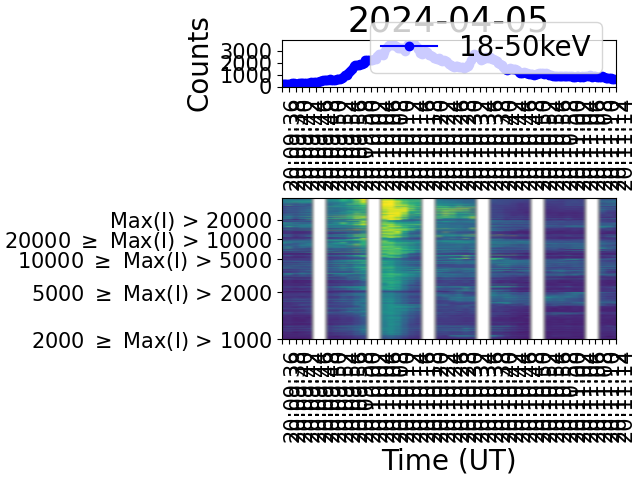

In [40]:
axes = plt.figure(layout="constrained").subplot_mosaic(
    """
    aa
    bb
    bb
    bb
    """
    # # set the height ratios between the rows
    # height_ratios=[1, 1],
    # # set the width ratios between the columns
    # width_ratios=[1, 1],
)

#axes['a'].plot(stix_time[334:534].value, non_thermal_energies[334:534])

axes['a'].plot(stix_time[338:534].value, non_thermal_energies[338:534], 'bo-', label = "18-50keV")
axes['a'].set_xticks(stix_tick, eui_times_labels[20:70], rotation=90, ha="right", rotation_mode="anchor", fontsize = 15)
axes['a'].set_xlim(stix_time[338].value, stix_time[534].value)
axes['a'].set_yticks([0,1000,2000,3000], labels = ["0", "1000", "2000", "3000"], fontsize = 15)
axes['a'].set_ylabel("Counts", fontsize = 20)
axes['a'].legend(fontsize = 20)


im = axes['b'].imshow(np.log10(gapped_lightcurves_all), aspect = "auto")
cbar = axes['b'].figure.colorbar(im, ax=ax)#, label="")#, fontsize = 20)
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Log(Intensity)', size=20)

# ax.axvline([24])
# ax.axvline([25])
# ax.axvline([26])
# ax.axvline([29])
# ax.axvline([30])
# ax.axvline([31])
# ax.axvline([38])
# ax.axvline([39])
# ax.axvline([46])
# ax.axvline([47])
# # Show all ticks and label them with the respective list entries
axes['b'].set_xticks(x_tick_locs, labels=eui_times_labels,#labels=eui_times_gapped,#
                rotation=90, ha="right", rotation_mode="anchor", fontsize = 15)
axes['b'].set_yticks(y_ticks, labels = y_labels, fontsize = 15)
# ax.set_yticks(range(len(vegetables)), labels=vegetables)

# # Loop over data dimensions and create text annotations.
# for i in range(len(vegetables)):
#     for j in range(len(farmers)):
#         text = ax.text(j, i, harvest[i, j],
#                        ha="center", va="center", color="w")

#axes['b'].set_title("2024-04-05", fontsize = 20)
axes['b'].set_xlabel("Time (UT)", fontsize = 20)
axes['b'].set_xlim([19,68])
axes['a'].set_title("2024-04-05", fontsize = 25)
# fig.tight_layout()
plt.show()